- `Acesso aos dados`: [MCD19A2.061: Terra & Aqua MAIAC Land Aerosol Optical Depth Daily 1km ](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES)
- `Período dos dados`: 2000-02-24T00:00:00Z–2024-05-16T23:55:00Z
- `Resolução espacial`: 1000 metros
- `Resolução temporal`: diária
- `Variável utilizada`: Aerosol optical depth over land retrieved in the MODIS Green band (0.55 μm)
- `Código realizado por`: Enrique V. Mattos - 13/04/2025

# Preparando o ambiente

In [1]:
# instalações
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import xarray as xr
import os
import glob
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy, cartopy.crs as ccrs
import pandas as pd
import numpy as np
import salem
import ultraplot as uplt
import warnings
warnings.filterwarnings('ignore')

# monta drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes'

# diretório de saida dos arquivos netcdf
dir_input = f'{dir}/output/05_netcdf_aod_550nm_por_ano'

# diretório de saida dos arquivos de figura
dir_output = f'{dir}/output'

# limites do Brasil
lonmin_BR, lonmax_BR, latmin_BR, latmax_BR = -75.0, -33.0, -35.0, 7.0

# limites de MG
lonmin_MG, lonmax_MG, latmin_MG, latmax_MG = -52., -39., -23., -14.

# limites de SP
lonmin_SP, lonmax_SP, latmin_SP, latmax_SP = -53.3, -43.9, -25.4, -19.7

# leitura do shapefile de SP
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.0 MB/s eta 0:00:00
Mounted at /content/drive


# Plota painel de figuras - `MÉDIA`

## Leitura dos dados e cálculo de anomalia

In [2]:
ds = xr.open_dataset(f'{dir_input}/AOD_055_MODIS_mean_anual_2024_sp_20km.nc')
ds

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 1, lat: 28, lon: 45)
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-01-01
  * lat      (lat) float64 224B -25.21 -25.01 -24.81 ... -20.21 -20.01 -19.81
  * lon      (lon) float64 360B -53.01 -52.81 -52.61 ... -44.61 -44.41 -44.21
Data variables:
    AOD_550  (time, lat, lon) float32 5kB ...
Attributes:
    crs:      EPSG:4326

In [3]:
# leitura do shapefile de SP
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp')

# lista dos arquivos
files = sorted(glob.glob(f'{dir_input}/AOD_055_MODIS_mean_anual_*.nc')) # AOD_055_MODIS_mean_anual_2003_20km.nc

# leitura dos arquivos por ano
aod_por_ano = xr.open_mfdataset(files, concat_dim='time', combine='nested')

# coloca "NaN" onde os "focos=0"
condicao = aod_por_ano['AOD_550'][:,:,:] == 0
aod_por_ano['AOD_550'][:,:,:] = np.where(condicao, np.nan, aod_por_ano['AOD_550'][:,:,:])

# calculando a CLIMATOLOGIA: 2003-2023
climatologia = aod_por_ano.sel(time=slice('2003-01-01','2023-12-31')).mean("time")

# calculando a ANOMALIA
anomalia = aod_por_ano['AOD_550'] - climatologia

# recorta o dado para região
anomalia = anomalia.salem.roi(shape=shapefile_sp)
climatologia = climatologia.salem.roi(shape=shapefile_sp)

In [4]:
climatologia

<xarray.Dataset> Size: 6kB
Dimensions:  (lat: 28, lon: 45)
Coordinates:
  * lat      (lat) float64 224B -25.21 -25.01 -24.81 ... -20.21 -20.01 -19.81
  * lon      (lon) float64 360B -53.01 -52.81 -52.61 ... -44.61 -44.41 -44.21
Data variables:
    AOD_550  (lat, lon) float32 5kB dask.array<chunksize=(28, 45), meta=np.ndarray>
Attributes:
    crs:         EPSG:4326
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

In [5]:
anomalia

<xarray.Dataset> Size: 112kB
Dimensions:  (time: 22, lat: 28, lon: 45)
Coordinates:
  * time     (time) datetime64[ns] 176B 2003-01-01 2004-01-01 ... 2024-01-01
  * lat      (lat) float64 224B -25.21 -25.01 -24.81 ... -20.21 -20.01 -19.81
  * lon      (lon) float64 360B -53.01 -52.81 -52.61 ... -44.61 -44.41 -44.21
Data variables:
    AOD_550  (time, lat, lon) float32 111kB dask.array<chunksize=(1, 28, 45), meta=np.ndarray>
Attributes:
    crs:            EPSG:4326
    id:             Optical_Depth_055
    data_type:      {'type': 'PixelType', 'precision': 'double', 'min': -32.7...
    crs_transform:  [1 0 0 0 1 0]
    pyproj_srs:     +proj=longlat +datum=WGS84 +no_defs

## Plota Figura

Processando o ano: .... 0 , 2003
Processando o ano: .... 1 , 2004
Processando o ano: .... 2 , 2005
Processando o ano: .... 3 , 2006
Processando o ano: .... 4 , 2007
Processando o ano: .... 5 , 2008
Processando o ano: .... 6 , 2009
Processando o ano: .... 7 , 2010
Processando o ano: .... 8 , 2011
Processando o ano: .... 9 , 2012
Processando o ano: .... 10 , 2013
Processando o ano: .... 11 , 2014
Processando o ano: .... 12 , 2015
Processando o ano: .... 13 , 2016
Processando o ano: .... 14 , 2017
Processando o ano: .... 15 , 2018
Processando o ano: .... 16 , 2019
Processando o ano: .... 17 , 2020
Processando o ano: .... 18 , 2021
Processando o ano: .... 19 , 2022
Processando o ano: .... 20 , 2023
Processando o ano: .... 21 , 2024
CPU times: user 8.78 s, sys: 706 ms, total: 9.49 s
Wall time: 14.4 s


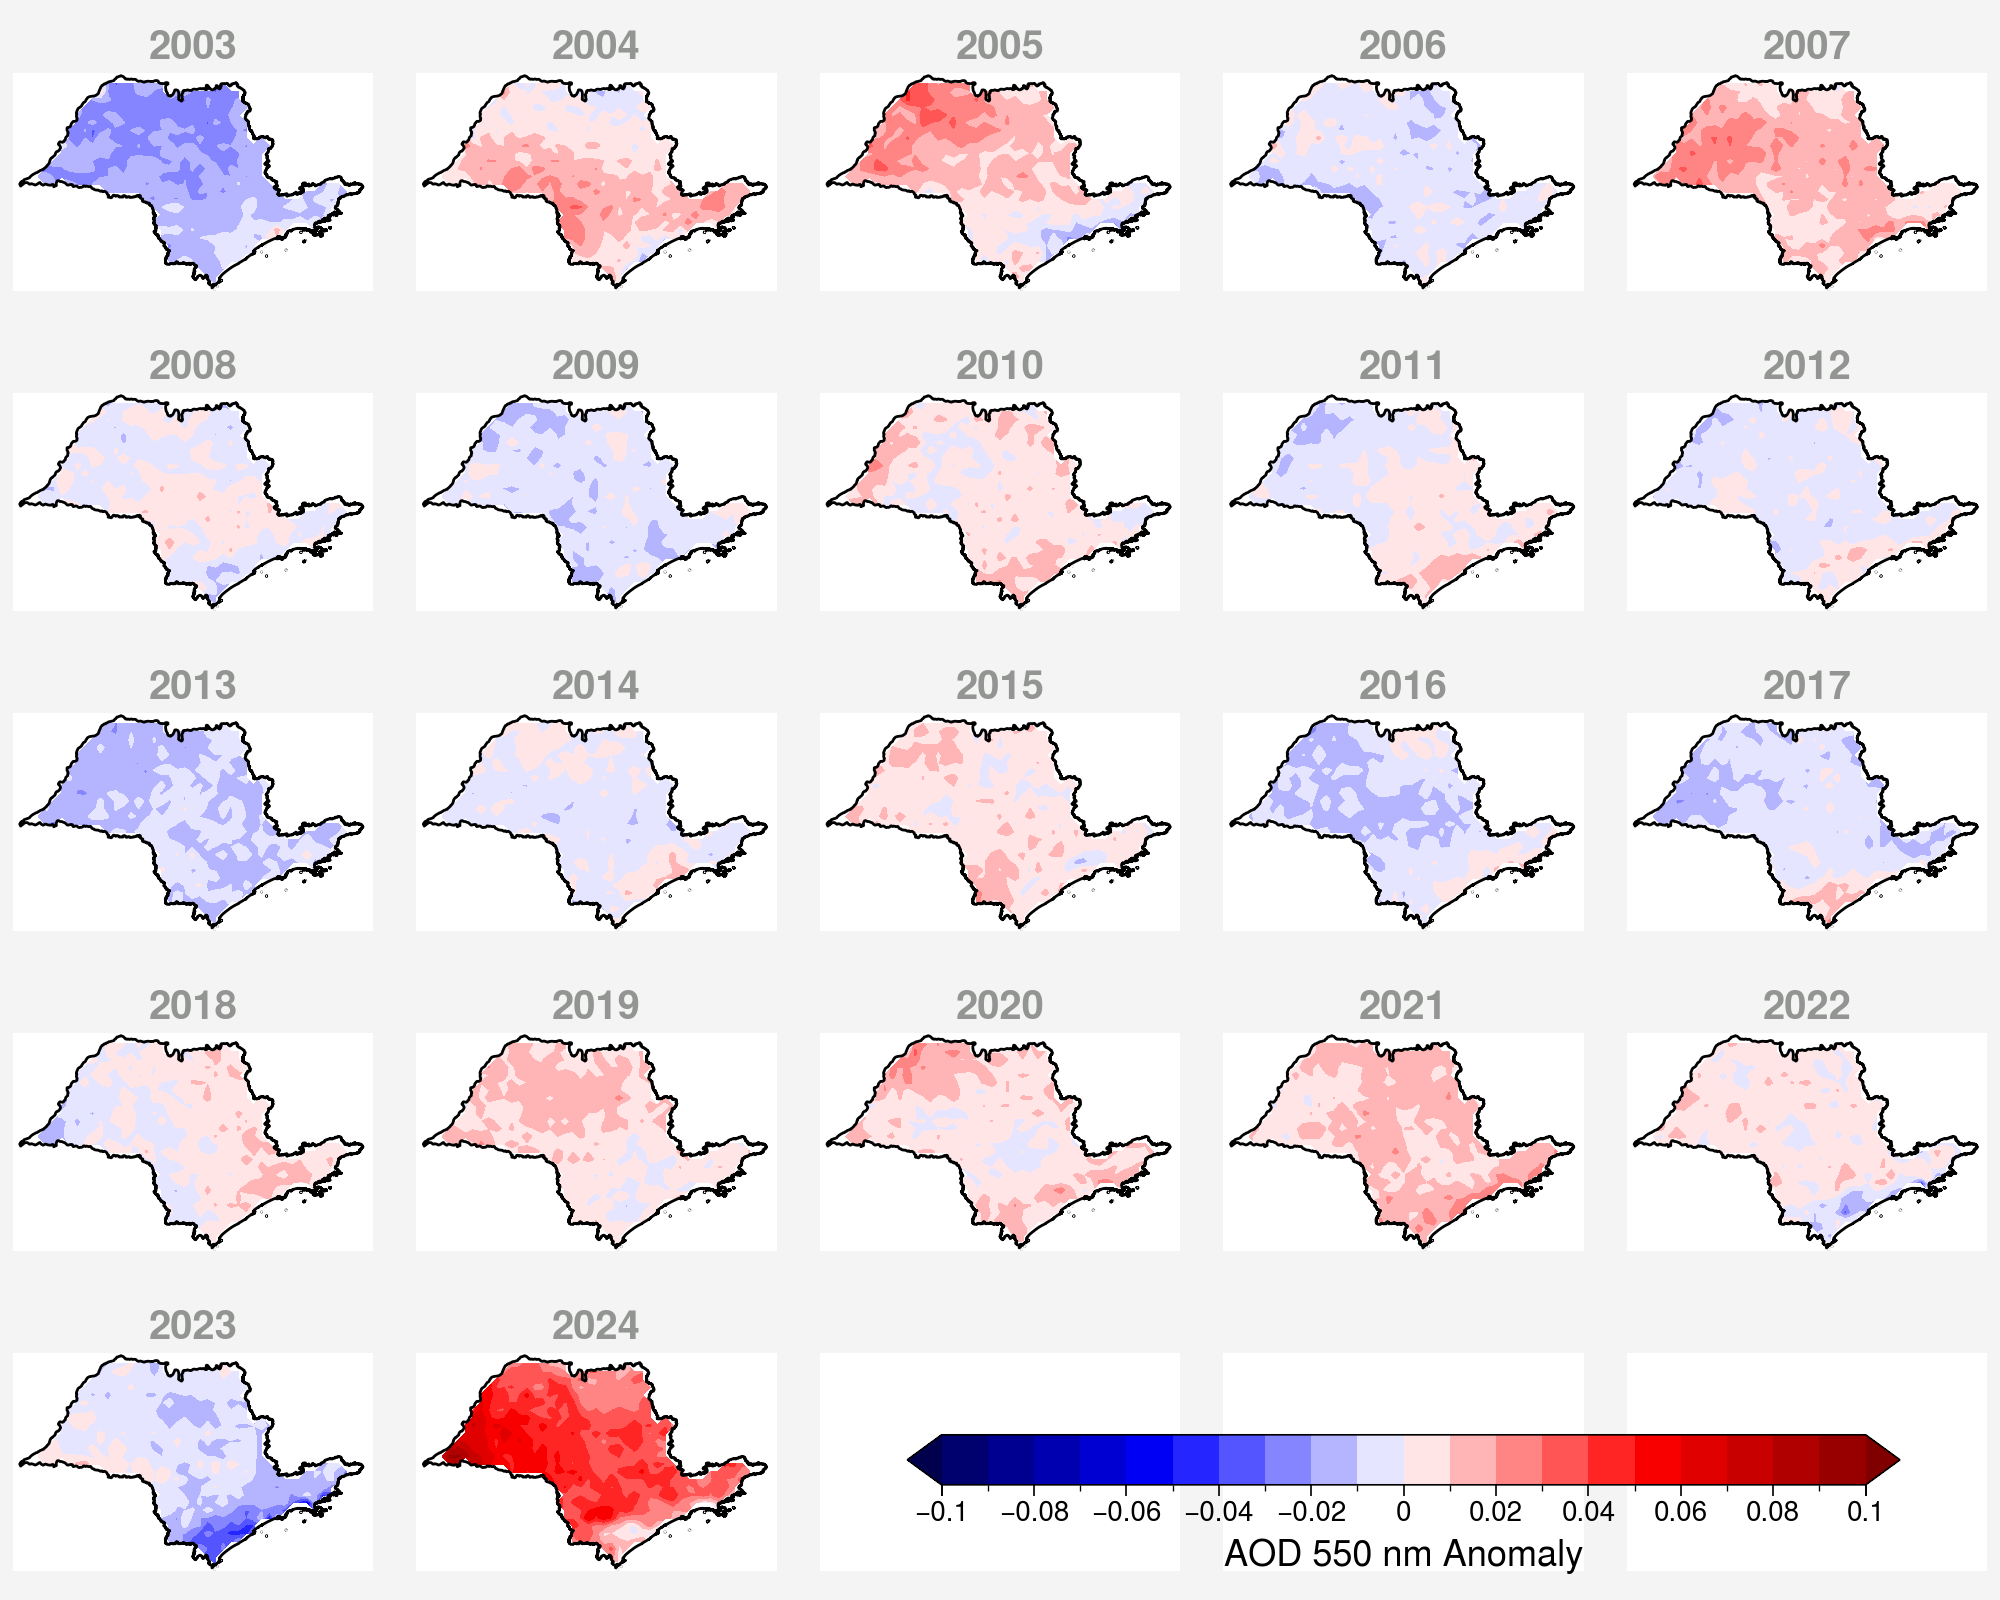

In [6]:
%%time
# cria a moldura da figura
fig, ax = uplt.subplots(figsize=(10, 8),
                        nrows=5, ncols=5,
                        tight=True,
                        proj='pcarree',
                        sharex=True, sharey=True)

# formatação dos eixos
ax.format(coast=False, borders=False, innerborders=False,
          labels=False, latlines=5, lonlines=10,
          latlim=(latmin_SP, latmax_SP), lonlim=(lonmin_SP, lonmax_SP),
          small='5px', large='20px',
          linewidth=0, grid=False)

# loop dos anos
for i, ano in enumerate(np.arange(2003, 2025)):

  # exibe na tela o ano que esta sendo processado
  print(f'Processando o ano: .... {i} , {ano}')

  # plota figura
  map1 = ax[i].contourf(anomalia['lon'],
                        anomalia['lat'],
                        anomalia['AOD_550'][i,:,:],
                        cmap='seismic',
                        vmin=-0.1, vmax=0.1,
                        levels=uplt.arange(-0.1, 0.1, 0.01),
                        extend='both')

  # plota titulo de cada figura
  ax[i].format(title=str(ano), labels = False, titleloc='c', titlecolor='grey', titleweight='bold', small='5px')

  # plota shapefile de SP
  shapefile = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
  ax[i].add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.0)

# plota barra de cores da figura
fig.colorbar(map1,
             loc='b',
             label='AOD 550 nm Anomaly',
             ticks=0.02,
             ticklabelsize=10,
             labelsize=13,
             length=0.85,
             width=0.25,
             space=-7,
             cols=(3,5))

# salva figura
fig.savefig(f'{dir_output}/Fig_8a_anomalia_AOD_mean_anual_sp_20km.jpg', transparent=True, dpi=300, bbox_inches="tight")

#  Plota painel de figuras - `MÁXIMO`

## Leitura dos dados e cálculo de anomalia

In [8]:
#ds = xr.open_dataset(f'{dir_input}/AOD_055_MODIS_max_anual_2024_20km.nc')
#ds

In [9]:
# lista dos arquivos
files = sorted(glob.glob(f'{dir_input}/AOD_055_MODIS_max_anual_*.nc')) # AOD_055_MODIS_max_anual_2003_20km.nc

# leitura dos arquivos por ano
aod_por_ano = xr.open_mfdataset(files, concat_dim='time', combine='nested')

# coloca "NaN" onde os "focos=0"
condicao = aod_por_ano['AOD_550'][:,:,:] == 0
aod_por_ano['AOD_550'][:,:,:] = np.where(condicao, np.nan, aod_por_ano['AOD_550'][:,:,:])

# calculando a CLIMATOLOGIA: 2003-2023
climatologia = aod_por_ano.sel(time=slice('2003-01-01','2023-12-31')).mean("time")

# calculando a ANOMALIA
anomalia = aod_por_ano['AOD_550'] - climatologia

# recorta o dado para região
anomalia = anomalia.salem.roi(shape=shapefile_sp)
climatologia = climatologia.salem.roi(shape=shapefile_sp)

In [10]:
climatologia

<xarray.Dataset> Size: 6kB
Dimensions:  (lat: 28, lon: 45)
Coordinates:
  * lat      (lat) float64 224B -25.21 -25.01 -24.81 ... -20.21 -20.01 -19.81
  * lon      (lon) float64 360B -53.01 -52.81 -52.61 ... -44.61 -44.41 -44.21
Data variables:
    AOD_550  (lat, lon) float32 5kB dask.array<chunksize=(28, 45), meta=np.ndarray>
Attributes:
    crs:         EPSG:4326
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

In [11]:
anomalia

<xarray.Dataset> Size: 112kB
Dimensions:  (time: 22, lat: 28, lon: 45)
Coordinates:
  * time     (time) datetime64[ns] 176B 2003-01-01 2004-01-01 ... 2024-01-01
  * lat      (lat) float64 224B -25.21 -25.01 -24.81 ... -20.21 -20.01 -19.81
  * lon      (lon) float64 360B -53.01 -52.81 -52.61 ... -44.61 -44.41 -44.21
Data variables:
    AOD_550  (time, lat, lon) float32 111kB dask.array<chunksize=(1, 28, 45), meta=np.ndarray>
Attributes:
    crs:            EPSG:4326
    id:             Optical_Depth_055
    data_type:      {'type': 'PixelType', 'precision': 'double', 'min': -32.7...
    crs_transform:  [1 0 0 0 1 0]
    pyproj_srs:     +proj=longlat +datum=WGS84 +no_defs

## Plota Figura

Processando o ano: .... 0 , 2003
Processando o ano: .... 1 , 2004
Processando o ano: .... 2 , 2005
Processando o ano: .... 3 , 2006
Processando o ano: .... 4 , 2007
Processando o ano: .... 5 , 2008
Processando o ano: .... 6 , 2009
Processando o ano: .... 7 , 2010
Processando o ano: .... 8 , 2011
Processando o ano: .... 9 , 2012
Processando o ano: .... 10 , 2013
Processando o ano: .... 11 , 2014
Processando o ano: .... 12 , 2015
Processando o ano: .... 13 , 2016
Processando o ano: .... 14 , 2017
Processando o ano: .... 15 , 2018
Processando o ano: .... 16 , 2019
Processando o ano: .... 17 , 2020
Processando o ano: .... 18 , 2021
Processando o ano: .... 19 , 2022
Processando o ano: .... 20 , 2023
Processando o ano: .... 21 , 2024
CPU times: user 8.07 s, sys: 229 ms, total: 8.3 s
Wall time: 8.64 s


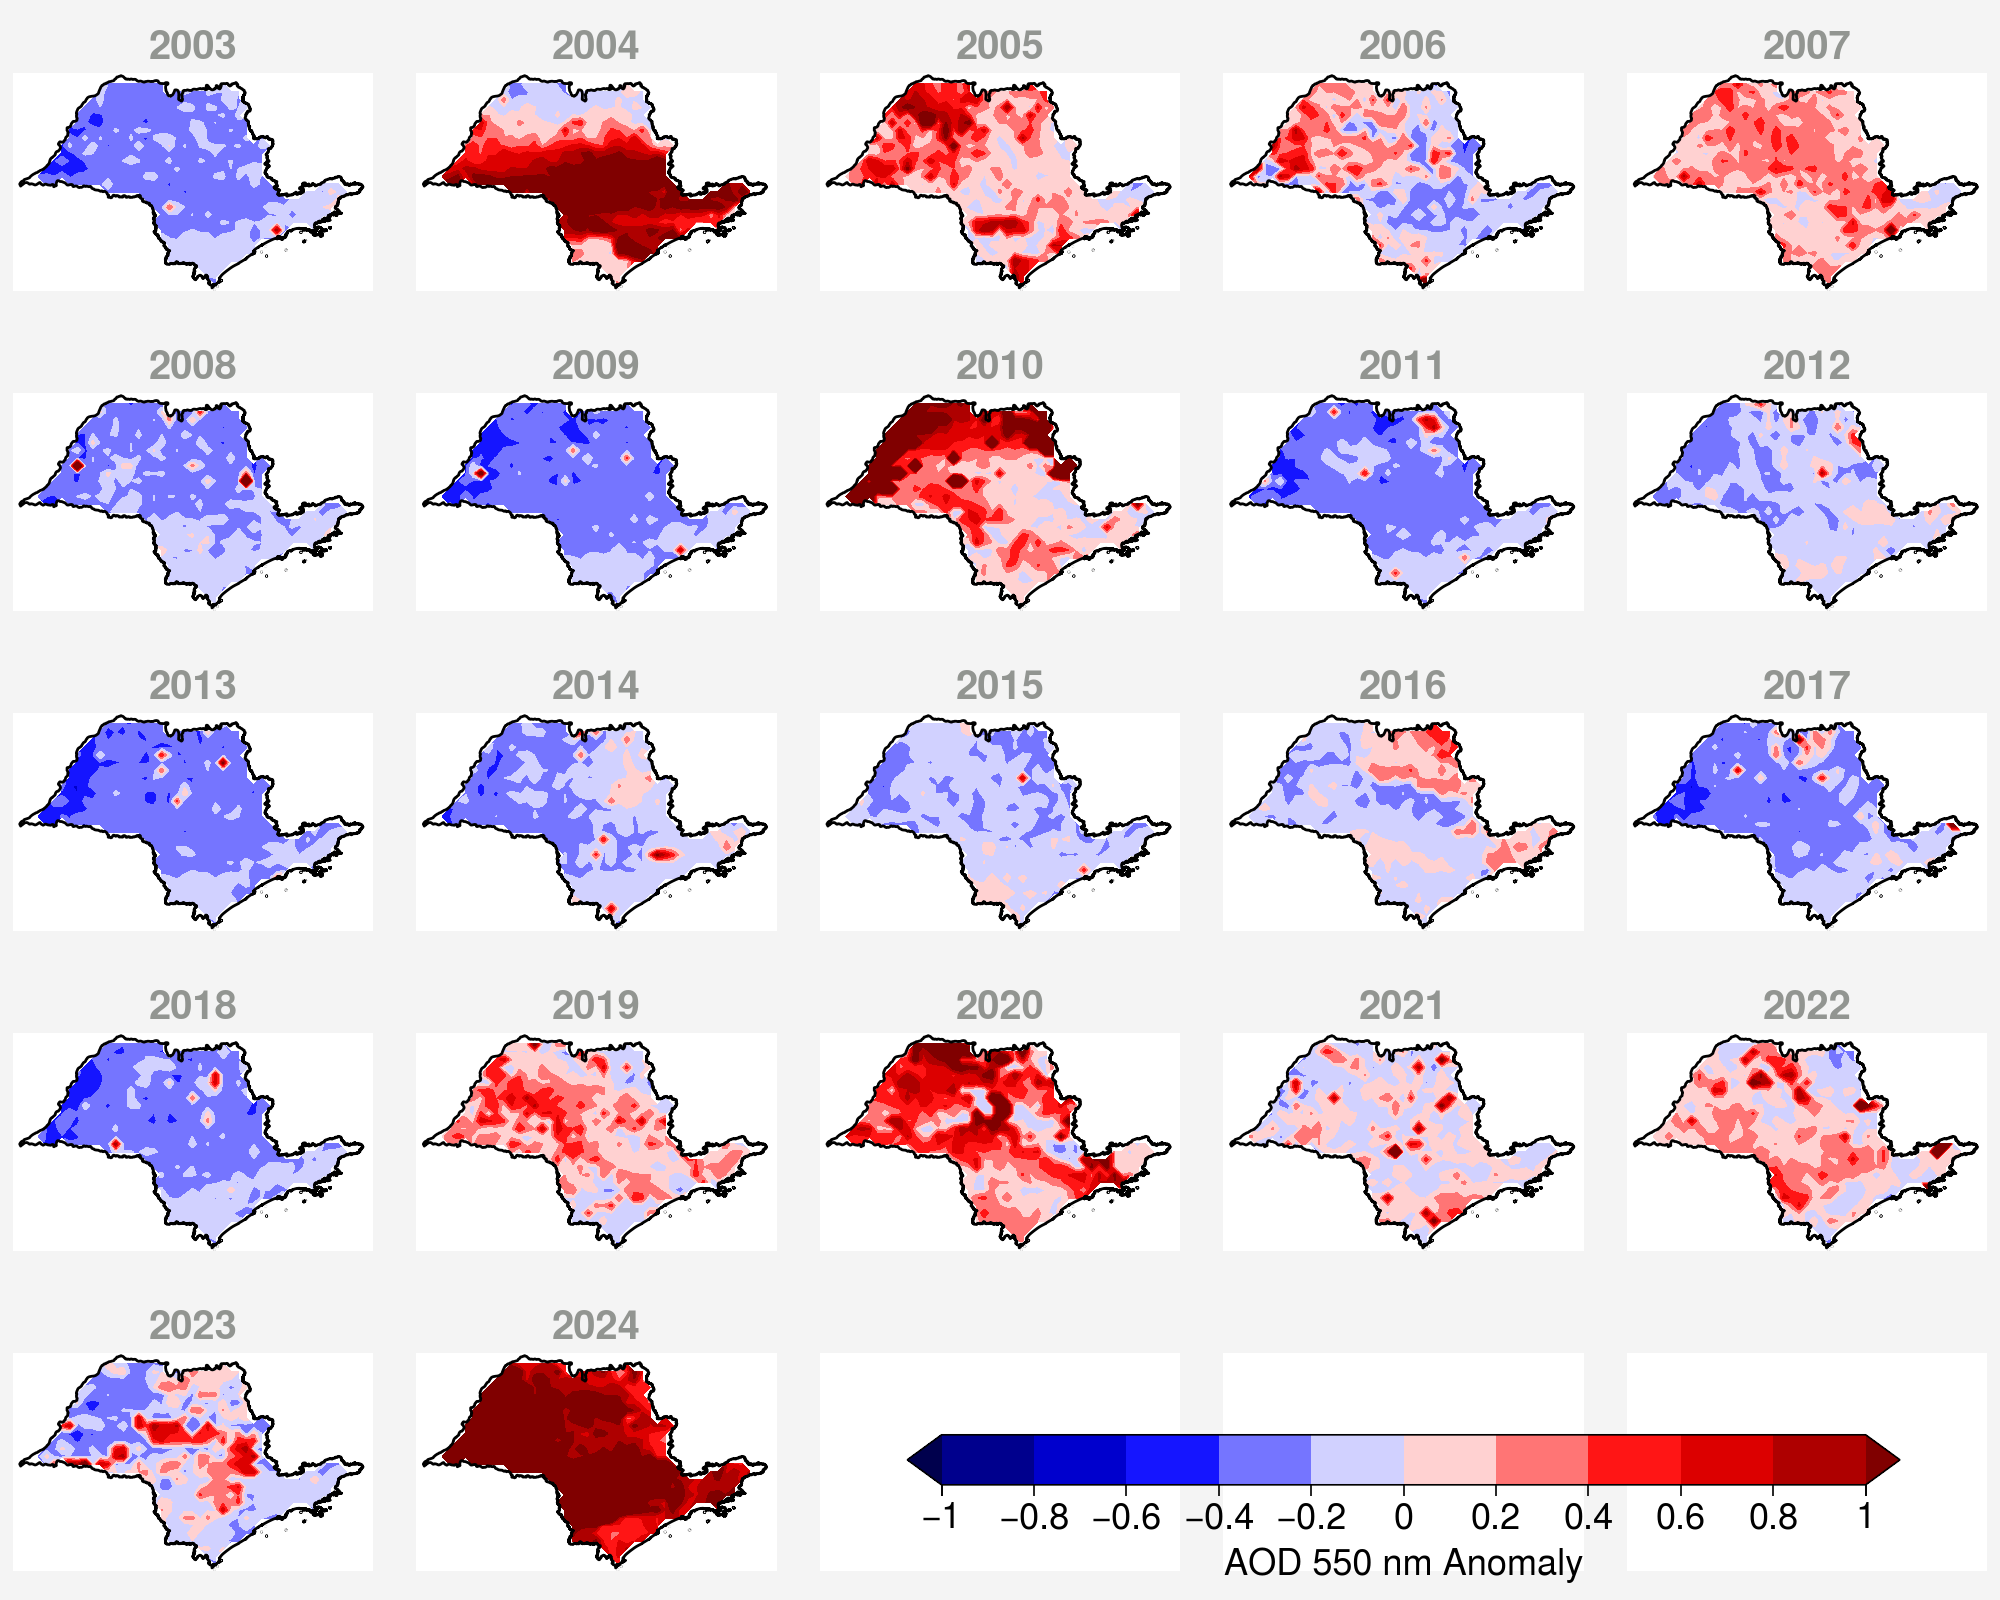

In [12]:
%%time
# cria a moldura da figura
fig, ax = uplt.subplots(figsize=(10, 8),
                        nrows=5, ncols=5,
                        tight=True,
                        proj='pcarree',
                        sharex=True, sharey=True)

# formatação dos eixos
ax.format(coast=False, borders=False, innerborders=False,
          labels=False, latlines=5, lonlines=10,
          latlim=(latmin_SP, latmax_SP), lonlim=(lonmin_SP, lonmax_SP),
          small='5px', large='20px',
          linewidth=0, grid=False)

# loop dos anos - Use the years available in the anomalia dataset
for i, ano in enumerate(anomalia.time.dt.year.values):

  # exibe na tela o ano que esta sendo processado
  print(f'Processando o ano: .... {i} , {ano}')

  # plota figura
  map1 = ax[i].contourf(anomalia['lon'],
                        anomalia['lat'],
                        anomalia['AOD_550'][i,:,:],
                        cmap='seismic',
                        vmin=-1, vmax=1,
                        levels=uplt.arange(-1, 1, 0.2),
                        extend='both')

  # plota titulo de cada figura
  ax[i].format(title=str(ano), labels = False, titleloc='c', titlecolor='grey', titleweight='bold', small='5px')

  # plota shapefile de SP
  shapefile = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
  ax[i].add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.0)

# plota barra de cores da figura
fig.colorbar(map1,
             loc='b',
             label='AOD 550 nm Anomaly',
             ticks=0.2,
             ticklabelsize=13,
             labelsize=13,
             length=0.85,
             width=0.25,
             space=-7,
             cols=(3,5))

# salva figura
fig.savefig(f'{dir_output}/Fig_8b_anomalia_AOD_max_anual_sp_20km.jpg', transparent=True, dpi=300, bbox_inches="tight")